# Trader Segmentation & Clustering
In this notebook, we segment Hyperliquid trading accounts. We compute account-level profiles, apply dimensionality reduction (PCA), cluster accounts via KMeans, identify trader archetypes, and analyze their performance across sentiment regimes.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

ROOT = Path.cwd().parent
CSV = ROOT / 'csv_files'
OUT = ROOT / 'outputs'
SEED = 42

## Aggregate Account Metrics

In [2]:
df = pd.read_csv(ROOT / 'data' / 'historical_with_features.csv')
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'])

acc = df.groupby('Account').agg(
    trades=('Closed PnL', 'size'),
    win_rate=('y', 'mean'),
    avg_pnl=('Closed PnL_w', 'mean'),
    pnl_std=('Closed PnL_w', 'std'),
    total_pnl=('Closed PnL', 'sum'),
    volume=('Size USD', 'sum'),
    maker_rate=('Crossed', lambda x: (x == False).mean()),
    taker_rate=('Crossed', lambda x: (x == True).mean()),
    avg_fee=('Fee', 'mean'),
).reset_index()

acc['pnl_sharpe_proxy'] = acc['avg_pnl'] / acc['pnl_std'].replace(0, np.nan)
acc['profit_per_musd'] = acc['total_pnl'] / (acc['volume'] / 1e6).replace(0, np.nan)

# Compute max drawdown proxy per account
t = df.sort_values('timestamp_utc').copy()
t['cum_pnl'] = t.groupby('Account')['Closed PnL'].cumsum()
t['roll_max'] = t.groupby('Account')['cum_pnl'].cummax()
t['dd'] = t['cum_pnl'] - t['roll_max']
dd = t.groupby('Account')['dd'].min().rename('max_drawdown').reset_index()

acc = acc.merge(dd, on='Account', how='left')
acc['calmar_proxy'] = acc['total_pnl'] / acc['max_drawdown'].abs().replace(0, np.nan)
acc = acc.replace([np.inf, -np.inf], np.nan).fillna(0)
acc.head(5)

,Account,trades,win_rate,avg_pnl,pnl_std,total_pnl,volume,maker_rate,taker_rate,avg_fee,pnl_sharpe_proxy,profit_per_musd,max_drawdown,calmar_proxy
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,0.359612,122.356302,301.263979,1.600230e+06,61697263.97,0.887899,0.112101,1.939579,0.406143,25936.803628,-327934.104256,4.879730
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7271,0.443268,8.928747,57.196328,4.788532e+04,12035486.94,0.224728,0.775272,0.375442,0.156107,3978.677452,-22505.512854,2.127715
2,0x271b280974205ca63b716753467d5a371de622ab,3807,0.302075,10.498313,80.976985,-7.043619e+04,33873440.14,0.345416,0.654584,2.437873,0.129646,-2079.392912,-132868.175087,-0.530121
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13301,0.438914,11.116521,57.784087,1.324648e+05,6757020.36,0.054582,0.945418,0.166782,0.192380,19604.027737,-20849.886790,6.353263
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,0.519914,43.279379,138.897170,1.686580e+05,10166880.20,0.242667,0.757333,0.959616,0.311593,16588.963544,-3323.090682,50.753356


## Standardize Features and Apply PCA

In [3]:
features_to_cluster = ['trades', 'win_rate', 'avg_pnl', 'pnl_std', 'maker_rate', 'avg_fee', 'profit_per_musd', 'max_drawdown']
X = acc[features_to_cluster].copy()
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

pca = PCA(n_components=2, random_state=SEED)
Z = pca.fit_transform(X_scaled)
acc['pc1'] = Z[:, 0]
acc['pc2'] = Z[:, 1]
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

Explained variance ratio: [0.35836582 0.18393366]


## Cluster Accounts via KMeans (Behavioral Archetypes)

In [4]:
kmeans = KMeans(n_clusters=4, random_state=SEED, n_init=30)
acc['cluster'] = kmeans.fit_predict(X_scaled)

cluster_profiles = acc.groupby('cluster')[['trades', 'win_rate', 'avg_pnl', 'maker_rate', 'pnl_sharpe_proxy', 'max_drawdown']].mean().round(3)
cluster_profiles

,trades,win_rate,avg_pnl,maker_rate,pnl_sharpe_proxy,max_drawdown
cluster,,,,,,
0,3662.250,0.349,70.466,0.826,0.295,-263361.769
1,1250.444,0.419,100.517,0.560,0.410,-10316.741
2,8212.000,0.400,42.133,0.119,0.265,-90211.370
3,10033.562,0.411,21.981,0.432,0.208,-28459.093


## Plot PCA Behavioral Clusters and Account Skill Maps

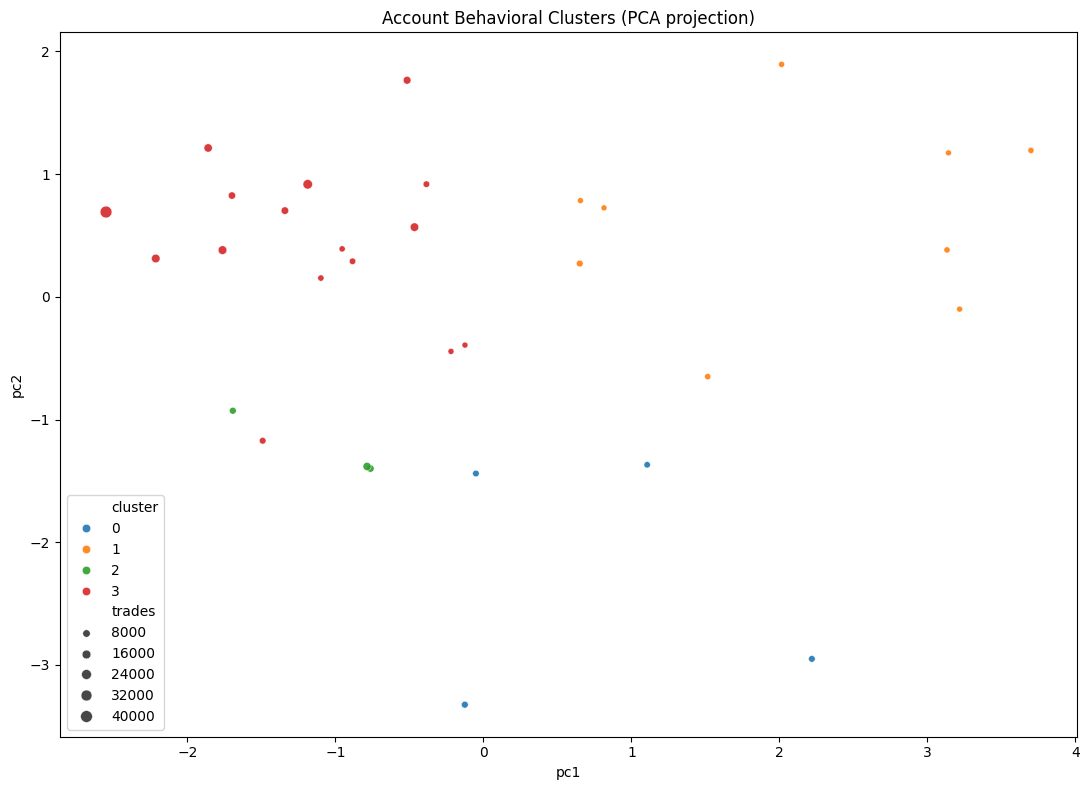

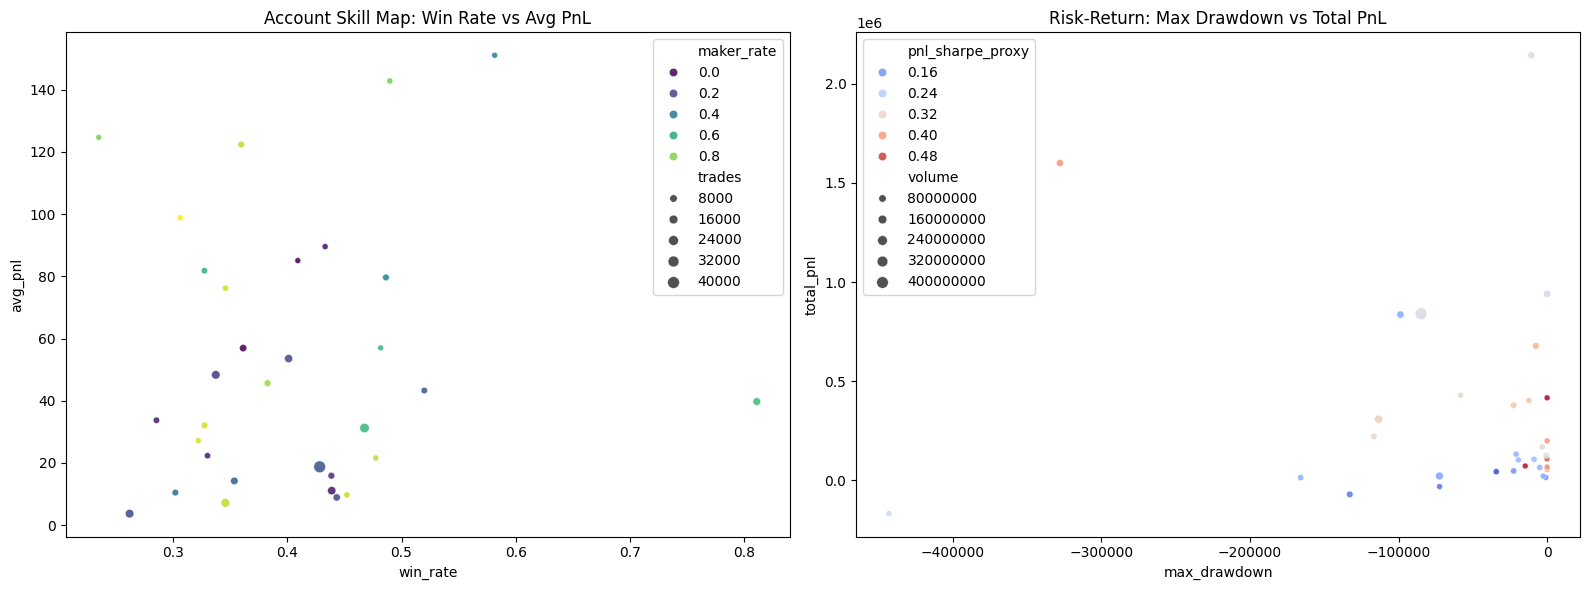

In [5]:
plt.figure(figsize=(11, 8))
sns.scatterplot(data=acc, x='pc1', y='pc2', hue='cluster', size='trades', palette='tab10', alpha=0.9)
plt.title('Account Behavioral Clusters (PCA projection)')
plt.tight_layout()
plt.savefig(OUT / 'figures/quant_account_clusters_pca.png', dpi=180, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=acc, x='win_rate', y='avg_pnl', size='trades', hue='maker_rate', palette='viridis', ax=axes[0], alpha=0.85)
axes[0].set_title('Account Skill Map: Win Rate vs Avg PnL')
sns.scatterplot(data=acc, x='max_drawdown', y='total_pnl', size='volume', hue='pnl_sharpe_proxy', palette='coolwarm', ax=axes[1], alpha=0.85)
axes[1].set_title('Risk-Return: Max Drawdown vs Total PnL')
plt.tight_layout()
plt.savefig(OUT / 'figures/quant_account_skill_risk_map.png', dpi=180, bbox_inches='tight')
plt.show()

## Regime Specialization Heatmap
We analyze how these accounts perform in Fear vs Greed regimes.

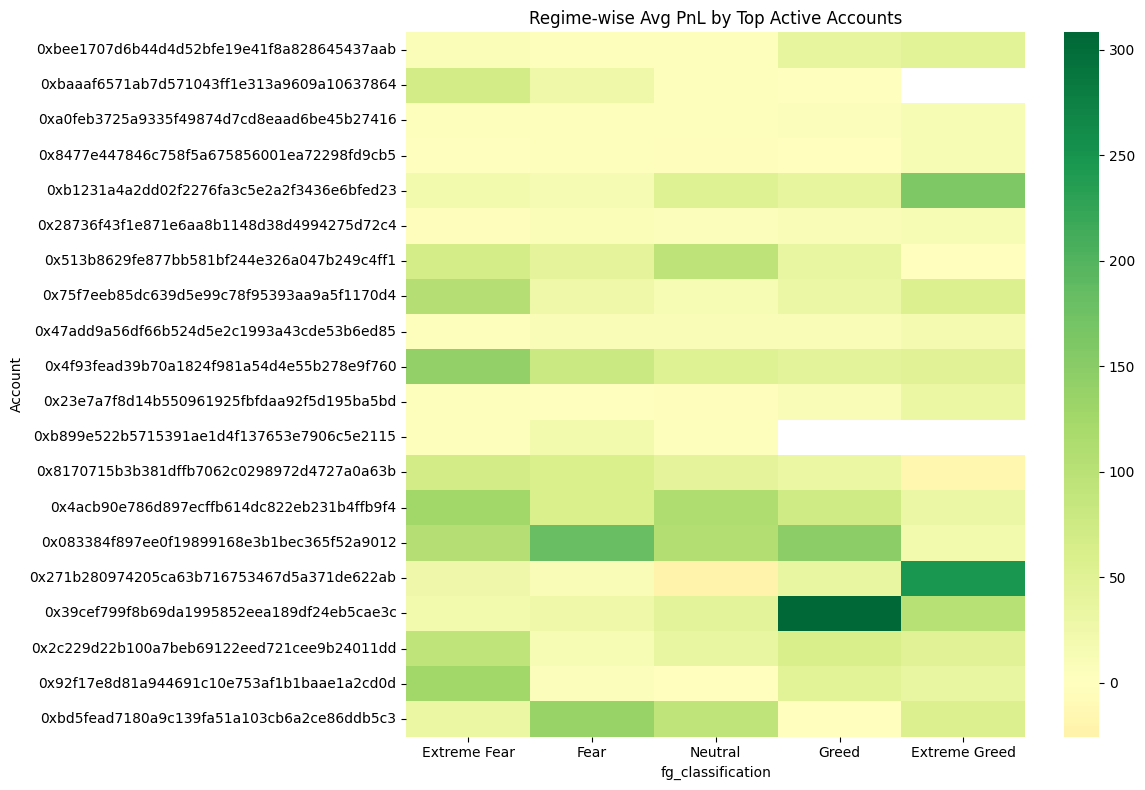

In [6]:
ar = df.groupby(['Account', 'fg_classification']).agg(
    avg_pnl=('Closed PnL_w', 'mean')
).reset_index()

regime_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
pivot_pnl = ar.pivot(index='Account', columns='fg_classification', values='avg_pnl').reindex(columns=regime_order)

fear_mean = pivot_pnl[['Extreme Fear', 'Fear']].mean(axis=1)
greed_mean = pivot_pnl[['Greed', 'Extreme Greed']].mean(axis=1)
special = (greed_mean - fear_mean).rename('greed_minus_fear_pnl')

spec_df = pd.concat([special, acc.set_index('Account')[['trades', 'total_pnl', 'max_drawdown']]], axis=1).sort_values('greed_minus_fear_pnl', ascending=False)
spec_df.reset_index().rename(columns={'index': 'Account'}).to_csv(CSV / 'advanced_specialization_metrics.csv', index=False)
spec_df.reset_index().rename(columns={'index': 'Account'}).to_csv(ROOT / 'data' / 'advanced_specialization_metrics.csv', index=False)
acc.sort_values('total_pnl', ascending=False).to_csv(CSV / 'advanced_account_metrics.csv', index=False)
acc.sort_values('total_pnl', ascending=False).to_csv(ROOT / 'data' / 'advanced_account_metrics.csv', index=False)

# Heatmap of top active accounts
top_acc = acc.sort_values('trades', ascending=False).head(20)['Account']
heat = pivot_pnl.loc[top_acc]
plt.figure(figsize=(12, 8))
sns.heatmap(heat, cmap='RdYlGn', center=0)
plt.title('Regime-wise Avg PnL by Top Active Accounts')
plt.tight_layout()
plt.savefig(OUT / 'figures/quant_regime_specialization_heatmap.png', dpi=180, bbox_inches='tight')
plt.show()